Libraries Imported Successfully
Customers Data
   customer_id   name   age  gender    city    income
0          101  User1  38.0  Female     NaN       NaN
1          102  User2  26.0  Female   Delhi  900000.0
2          103  User3  45.0    Male    Pune  500000.0
3          104  User4  24.0    Male    Pune  900000.0
4          105  User5  29.0  Female  Mumbai  500000.0
(120, 6)
Transactions Data
  transaction_id  customer_id product_id  amount payment_mode
0           T001          179       P014    3244          UPI
1           T002          142       P017   40000         Cash
2           T003          144       P013   40000         Cash
3           T004          106       P021    2882         None
4           T005          144       P032   25000          UPI
(220, 5)
Products Data
  product_id product_name     category  price  stock
0       P001     Product1  Electronics   4973     78
1       P002     Product2  Electronics   2506     36
2       P003     Product3  Electronics   3439   

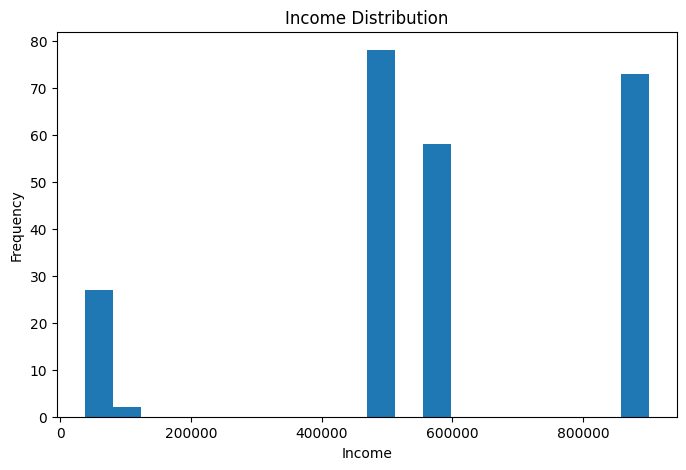

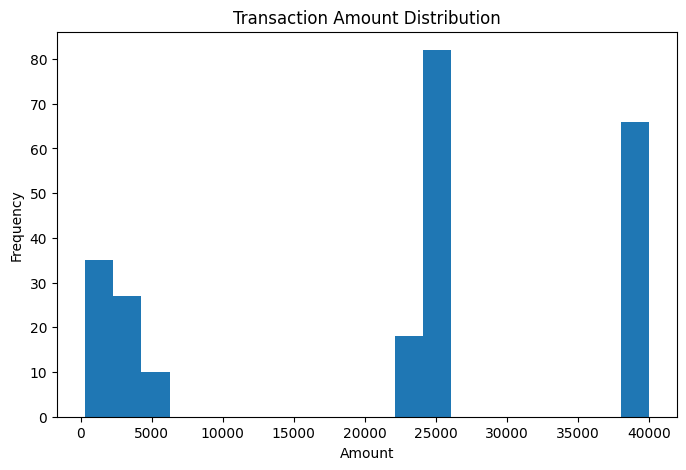

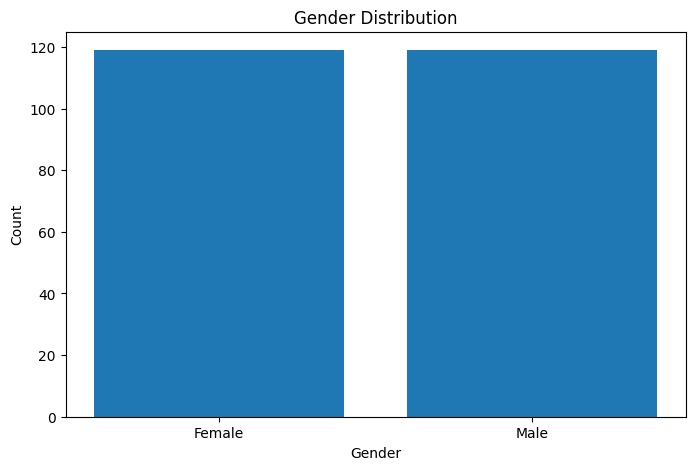

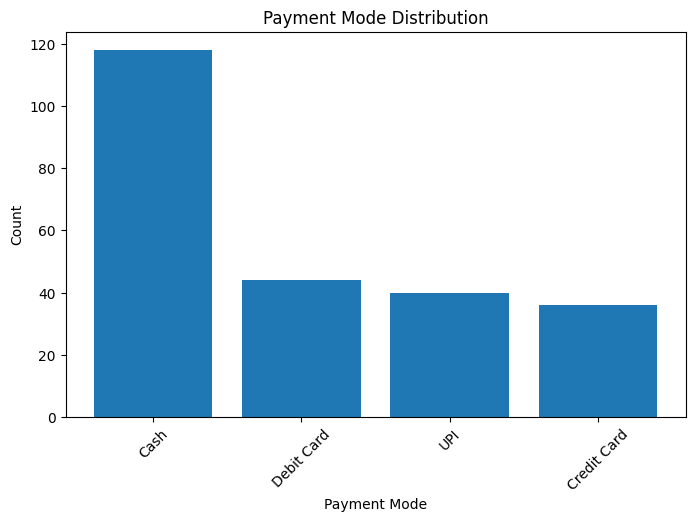

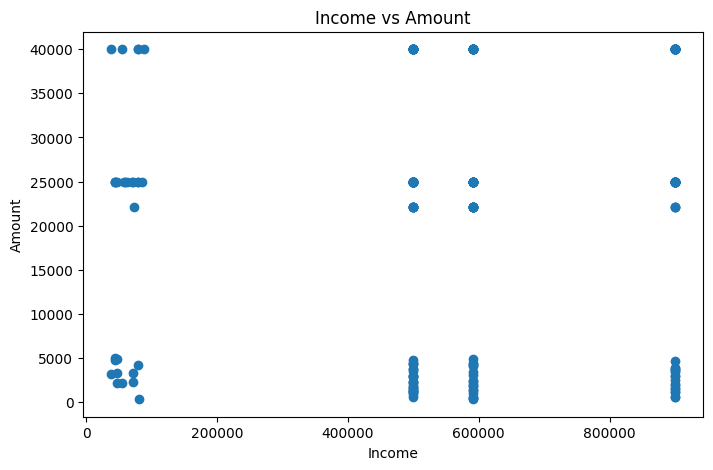

          income    amount     price     stock    height    weight
income  1.000000  0.140516  0.049680  0.004501  0.036471 -0.063243
amount  0.140516  1.000000 -0.021553 -0.035950 -0.061248 -0.063951
price   0.049680 -0.021553  1.000000 -0.068310 -0.121086 -0.137584
stock   0.004501 -0.035950 -0.068310  1.000000 -0.036461 -0.046043
height  0.036471 -0.061248 -0.121086 -0.036461  1.000000 -0.018823
weight -0.063243 -0.063951 -0.137584 -0.046043 -0.018823  1.000000


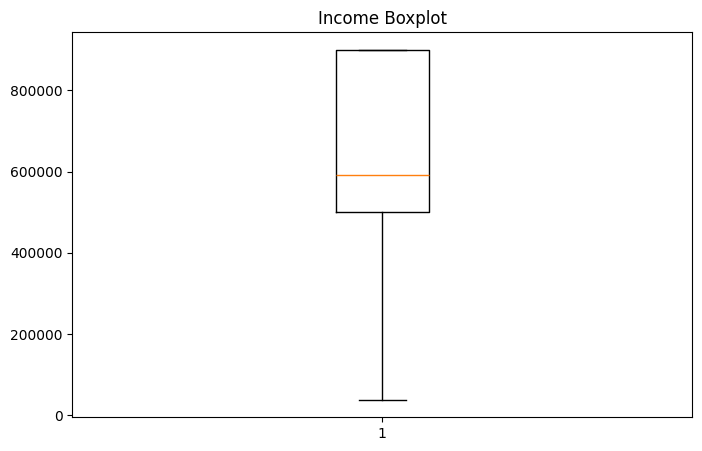

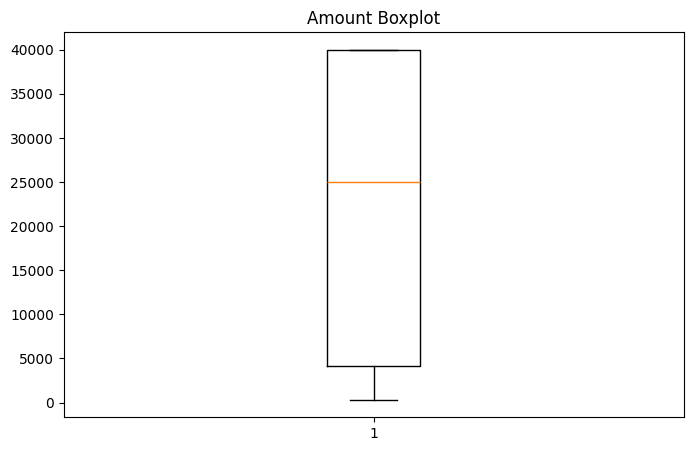

ID Column Removed
Transaction Missing Values Filled
customer_id       0
name              0
age               0
gender            0
city              0
income            0
transaction_id    0
product_id        0
amount            0
payment_mode      0
product_name      0
category          0
price             0
stock             0
firstName         0
lastName          0
api_age           0
api_gender        0
email             0
phone             0
height            0
weight            0
bloodGroup        0
dtype: int64
Z Score Outliers
[[False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False Fal

In [1]:
# ==========================================================
# CUSTOMER PURCHASE ANALYSIS PROJECT
# DATA PREPROCESSING AND FEATURE ENGINEERING
# ==========================================================

# STEP 1 : IMPORT LIBRARIES

import pandas as pd
import numpy as np
import json
import sqlite3
import requests
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import PowerTransformer

from scipy.stats import zscore
from scipy.stats.mstats import winsorize

print("Libraries Imported Successfully")


# ==========================================================
# STEP 2 : LOAD CUSTOMERS CSV
# ==========================================================

customers = pd.read_csv("customers.csv")

print("Customers Data")

print(customers.head())

print(customers.shape)


# ==========================================================
# STEP 3 : LOAD TRANSACTIONS JSON
# ==========================================================

with open("transactions.json", "r") as file:
    
    transactions = pd.DataFrame(json.load(file))

print("Transactions Data")

print(transactions.head())

print(transactions.shape)


# ==========================================================
# STEP 4 : CREATE SQL DATABASE
# ==========================================================

conn = sqlite3.connect("products.db")

cursor = conn.cursor()

with open("products.sql", "r") as sql_file:
    
    sql_script = sql_file.read()

cursor.executescript(sql_script)

products = pd.read_sql_query(
    "SELECT * FROM products",
    conn
)

print("Products Data")

print(products.head())

print(products.shape)


# ==========================================================
# STEP 5 : FETCH API DATA
# ==========================================================

url = "https://dummyjson.com/users"

response = requests.get(url)

data = response.json()["users"]

api_data = pd.json_normalize(data)

api_data = api_data[
[
'id',
'firstName',
'lastName',
'age',
'gender',
'email',
'phone',
'height',
'weight',
'bloodGroup'
]
]

api_data = api_data.rename(
    columns={
        'age':'api_age',
        'gender':'api_gender'
    }
)

print("API Data")

print(api_data.head())

print(api_data.shape)


# ==========================================================
# STEP 6 : MERGE CUSTOMERS + TRANSACTIONS
# ==========================================================

merged_data = pd.merge(
    customers,
    transactions,
    on="customer_id",
    how="left"
)

print("First Merge Done")

print(merged_data.head())


# ==========================================================
# STEP 7 : MERGE PRODUCTS
# ==========================================================

merged_data = pd.merge(
    merged_data,
    products,
    on="product_id",
    how="left"
)

print("Second Merge Done")

print(merged_data.head())


# ==========================================================
# STEP 8 : ATTACH API DATA
# ==========================================================

api_data = api_data.head(len(merged_data))

api_data.reset_index(
    drop=True,
    inplace=True
)

merged_data.reset_index(
    drop=True,
    inplace=True
)

final_df = pd.concat(
    [merged_data, api_data],
    axis=1
)

print("Final Merge Completed")

print(final_df.head())


# ==========================================================
# STEP 9 : CHECK COLUMNS
# ==========================================================

print("Columns Are")

print(final_df.columns)


# ==========================================================
# STEP 10 : MISSING VALUES CHECK
# ==========================================================

print("Missing Values")

print(final_df.isnull().sum())


# ==========================================================
# STEP 11 : BASIC INFORMATION
# ==========================================================

print(final_df.info())


# ==========================================================
# STEP 12 : DESCRIPTIVE STATS
# ==========================================================

print(final_df.describe())


# ==========================================================
# STEP 13 : SAVE RAW DATA
# ==========================================================

final_df.to_csv(
    "raw_merged_data.csv",
    index=False
)

# ==========================================================
# STEP 14 : HANDLE NUMERIC MISSING VALUES
# ==========================================================

numeric_columns = [
    'age',
    'income',
    'amount',
    'price',
    'stock',
    'api_age',
    'height',
    'weight'
]

simple_imputer = SimpleImputer(strategy="mean")

final_df[numeric_columns] = simple_imputer.fit_transform(
    final_df[numeric_columns]
)

print("Numeric Missing Values Filled")


# ==========================================================
# STEP 15 : HANDLE CATEGORICAL MISSING VALUES
# ==========================================================

categorical_columns = [
    'city',
    'payment_mode',
    'product_name',
    'category',
    'firstName',
    'lastName',
    'api_gender',
    'email',
    'phone',
    'bloodGroup'
]

for col in categorical_columns:

    final_df[col].fillna(
        final_df[col].mode()[0],
        inplace=True
    )

print("Categorical Missing Values Filled")


# ==========================================================
# STEP 16 : CHECK MISSING VALUES AGAIN
# ==========================================================

print(final_df.isnull().sum())


# ==========================================================
# STEP 17 : HISTOGRAM INCOME
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(final_df['income'], bins=20)

plt.title("Income Distribution")

plt.xlabel("Income")

plt.ylabel("Frequency")

plt.show()


# ==========================================================
# STEP 18 : HISTOGRAM AMOUNT
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(final_df['amount'], bins=20)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()


# ==========================================================
# STEP 19 : GENDER ANALYSIS
# ==========================================================

gender_counts = final_df["gender"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()


# ==========================================================
# STEP 20 : PAYMENT MODE ANALYSIS
# ==========================================================

payment_counts = final_df["payment_mode"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    payment_counts.index,
    payment_counts.values
)

plt.title("Payment Mode Distribution")

plt.xlabel("Payment Mode")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


# ==========================================================
# STEP 21 : SCATTER PLOT
# ==========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    final_df["income"],
    final_df["amount"]
)

plt.title("Income vs Amount")

plt.xlabel("Income")

plt.ylabel("Amount")

plt.show()


# ==========================================================
# STEP 22 : CORRELATION
# ==========================================================

correlation_data = final_df[
[
'income',
'amount',
'price',
'stock',
'height',
'weight'
]
]

print(correlation_data.corr())


# ==========================================================
# STEP 23 : BOXPLOT
# ==========================================================

plt.figure(figsize=(8,5))

plt.boxplot(final_df["income"])

plt.title("Income Boxplot")

plt.show()


plt.figure(figsize=(8,5))

plt.boxplot(final_df["amount"])

plt.title("Amount Boxplot")

plt.show()


# ==========================================================
# STEP 24 : SAVE STEP 2
# ==========================================================

final_df.to_csv(
    "cleaned_step2.csv",
    index=False
)

# ==========================================================
# STEP 25 : DROP USELESS API ID COLUMN
# ==========================================================

final_df = final_df.drop(
    columns=['id']
)

print("ID Column Removed")


# ==========================================================
# STEP 26 : FILL TRANSACTION MISSING VALUES
# ==========================================================

final_df['transaction_id'].fillna(
    "NO_TRANSACTION",
    inplace=True
)

final_df['product_id'].fillna(
    "NO_PRODUCT",
    inplace=True
)

print("Transaction Missing Values Filled")


# ==========================================================
# STEP 27 : CHECK FINAL MISSING VALUES
# ==========================================================

print(final_df.isnull().sum())


# ==========================================================
# STEP 28 : OUTLIER DETECTION USING Z SCORE
# ==========================================================

z_scores = np.abs(
    zscore(
        final_df[
            ['income','amount','price']
        ]
    )
)

outliers = (z_scores > 3)

print("Z Score Outliers")

print(outliers)


# ==========================================================
# STEP 29 : IQR METHOD
# ==========================================================

Q1 = final_df['income'].quantile(0.25)

Q3 = final_df['income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

iqr_outliers = final_df[
    (final_df['income'] < lower) |
    (final_df['income'] > upper)
]

print("IQR Outliers Found")

print(iqr_outliers[['customer_id','income']])


# ==========================================================
# STEP 30 : WINSORIZATION
# ==========================================================

final_df['amount'] = winsorize(
    final_df['amount'],
    limits=[0.05,0.05]
)

print("Winsorization Applied")


# ==========================================================
# STEP 31 : LABEL ENCODING
# ==========================================================

label_encoder = LabelEncoder()

final_df['gender_encoded'] = label_encoder.fit_transform(
    final_df['gender']
)

final_df['api_gender_encoded'] = label_encoder.fit_transform(
    final_df['api_gender']
)

print("Label Encoding Done")


# ==========================================================
# STEP 32 : ONE HOT ENCODING
# ==========================================================

final_df = pd.get_dummies(
    final_df,
    columns=[
        'payment_mode',
        'category',
        'bloodGroup'
    ]
)

print("One Hot Encoding Done")


# ==========================================================
# STEP 33 : CREATE HIGH VALUE CUSTOMER
# ==========================================================

final_df['high_value_customer'] = np.where(
    final_df['income'] > 500000,
    1,
    0
)

print("High Value Customer Feature Created")


# ==========================================================
# STEP 34 : PURCHASE CATEGORY
# ==========================================================

final_df['purchase_category'] = np.where(
    final_df['amount'] > 20000,
    "High Purchase",
    "Low Purchase"
)

print("Purchase Category Created")


# ==========================================================
# STEP 35 : PRODUCT NUMBER EXTRACTION
# ==========================================================

final_df['product_number'] = final_df['product_id'].astype(str).str.extract(
    '([0-9]+)'
)

print("Product Number Extracted")


# ==========================================================
# STEP 36 : CHECK DATA
# ==========================================================

print(final_df.head())


# ==========================================================
# STEP 37 : SAVE STEP 3
# ==========================================================

final_df.to_csv(
    "processed_step3.csv",
    index=False
)

# ==========================================================
# STEP 38 : SELECT NUMERIC COLUMNS
# ==========================================================

scale_columns = [
    'age',
    'income',
    'amount',
    'price',
    'stock',
    'api_age',
    'height',
    'weight'
]

print("Scaling Columns Selected")


# ==========================================================
# STEP 39 : STANDARD SCALER
# ==========================================================

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    final_df[scale_columns]
)

print("Standard Scaling Applied")


# ==========================================================
# STEP 40 : MIN MAX SCALER
# ==========================================================

minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(
    final_df[scale_columns]
)

print("Min Max Scaling Applied")


# ==========================================================
# STEP 41 : ROBUST SCALER
# ==========================================================

robust_scaler = RobustScaler()

robust_scaled = robust_scaler.fit_transform(
    final_df[scale_columns]
)

print("Robust Scaling Applied")


# ==========================================================
# STEP 42 : MAX ABS SCALER
# ==========================================================

maxabs_scaler = MaxAbsScaler()

maxabs_scaled = maxabs_scaler.fit_transform(
    final_df[scale_columns]
)

print("Max Abs Scaling Applied")


# ==========================================================
# STEP 43 : NORMALIZER
# ==========================================================

normalizer = Normalizer()

normalized_data = normalizer.fit_transform(
    final_df[scale_columns]
)

print("Normalization Applied")


# ==========================================================
# STEP 44 : LOG TRANSFORMATION
# ==========================================================

final_df['log_income'] = np.log(
    final_df['income'] + 1
)

print("Log Transformation Applied")


# ==========================================================
# STEP 45 : SQUARE ROOT TRANSFORMATION
# ==========================================================

final_df['sqrt_amount'] = np.sqrt(
    final_df['amount']
)

print("Square Root Transformation Applied")


# ==========================================================
# STEP 46 : RECIPROCAL TRANSFORMATION
# ==========================================================

final_df['reciprocal_price'] = 1 / (
    final_df['price'] + 1
)

print("Reciprocal Transformation Applied")


# ==========================================================
# STEP 47 : BOX COX TRANSFORMATION
# ==========================================================

boxcox = PowerTransformer(
    method='box-cox'
)

final_df['boxcox_income'] = boxcox.fit_transform(
    final_df[['income']]
)

print("Box Cox Applied")


# ==========================================================
# STEP 48 : YEO JOHNSON TRANSFORMATION
# ==========================================================

yeojohnson = PowerTransformer(
    method='yeo-johnson'
)

final_df['yeojohnson_amount'] = yeojohnson.fit_transform(
    final_df[['amount']]
)

print("Yeo Johnson Applied")


# ==========================================================
# STEP 49 : BINNING
# ==========================================================

final_df['income_group'] = pd.cut(
    final_df['income'],
    bins=3,
    labels=[
        'Low',
        'Medium',
        'High'
    ]
)

print("Income Binning Applied")


# ==========================================================
# STEP 50 : QUANTILE BINNING
# ==========================================================

# ==========================================================
# STEP 50 : QUANTILE BINNING
# ==========================================================

final_df['amount_group'] = pd.cut(
    final_df['amount'],
    bins=4
)

print("Amount Binning Applied")


# ==========================================================
# STEP 51 : FINAL EXPORT
# ==========================================================

final_df.to_csv(
    "processed_customer_data.csv",
    index=False
)


# ==========================================================
# STEP 52 : PROJECT COMPLETE
# ==========================================================

print("PROJECT COMPLETED SUCCESSFULLY")
print("ALL PREPROCESSING TECHNIQUES APPLIED")
